# 🎓 Career Prediction for Students — ML Pipeline
**Dataset:** 4.076 sampel | **Target:** 6 kategori karir | **Fitur:** teks skill mahasiswa  
**Workflow:** Text Preprocessing → TF-IDF → Train/Test Split → 4 Model → Evaluation → Interpretability

In [46]:
# # ── Cell 1: Install Dependencies ─────────────────────────────────────────────
%pip install xgboost shap --quiet

Note: you may need to restart the kernel to use updated packages.


In [47]:
# ── Cell 1b: Setup MLflow ─────────────────────────────────────────────────────

%pip install mlflow --quiet

Note: you may need to restart the kernel to use updated packages.


In [48]:
import mlflow
mlflow.set_experiment("Career_Prediction")   # nama eksperimen
print(f"✅ MLflow version: {mlflow.__version__}")
print(f"📁 Tracking URI: {mlflow.get_tracking_uri()}")

✅ MLflow version: 3.13.0
📁 Tracking URI: sqlite:///D:/BINUS/SEMESTER%204/Machine%20Learning/AOL/training/mlflow.db


In [49]:
# ── Cell 2: Import Libraries ──────────────────────────────────────────────────
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 120

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import shap

print('✅ Semua library berhasil dimuat.')

✅ Semua library berhasil dimuat.


In [50]:
# ── Cell 3a: Load Dataset ──────────────────────────────────────────────────────
# Kolom: 'Skill' (fitur teks) dan 'Career' (label target)
df = pd.read_csv('Career Dataset.csv')   # ganti path jika perlu

print(f'Shape  : {df.shape}')
print(f'Kolom  : {df.columns.tolist()}')
print(f'Missing: {df.isnull().sum().to_dict()}')
print(f"\nDistribusi Kelas (Career):")
print(df['Career'].value_counts())
df.head(3)

Shape  : (4076, 2)
Kolom  : ['Career', 'Skill']
Missing: {'Career': 0, 'Skill': 0}

Distribusi Kelas (Career):
Career
Development                                            1148
Artificial Intelligence                                 804
Software Development and Engineering                    714
Security                                                580
Data Science                                            558
User Experience (UX) and User Interface (UI) Design     272
Name: count, dtype: int64


,Career,Skill
0,Software Development and Engineering,"Web Development, Mobile App Development, Artif..."
1,Development,"Web Development, Mobile App Development, Probl..."
2,Data Science,"Data Analysis and Visualization, Deeplearning,..."



Panjang Skill Text (jumlah skill per record):
  Rata-rata : 5.9 skill
  Min       : 1 skill
  Max       : 37 skill

Interpretasi Panjang Skill:
  Rata-rata mahasiswa mencantumkan 5.9 skill dalam profilnya.

  Rata-rata jumlah skill per kelas karier:
    Software Development and Engineering : 12.7 skill
    Data Science                        : 5.9 skill
    Artificial Intelligence             : 5.3 skill
    Security                            : 4.7 skill
    Development                         : 3.5 skill
    User Experience (UX) and User Interface (UI) Design : 2.6 skill

Top 5 Skill Paling Sering per Kelas:

  [Software Development and Engineering]
    - Cybersecurity (398x)
    - Project Management (386x)
    - Web Development (368x)
    - Database Development (344x)
    - Problem Solving and Analysis (341x)

  [Development]
    - Web Development (762x)
    - Mobile App Development (449x)
    - Game Development (305x)
    - Problem Solving and Analysis (225x)
    - Web based proje

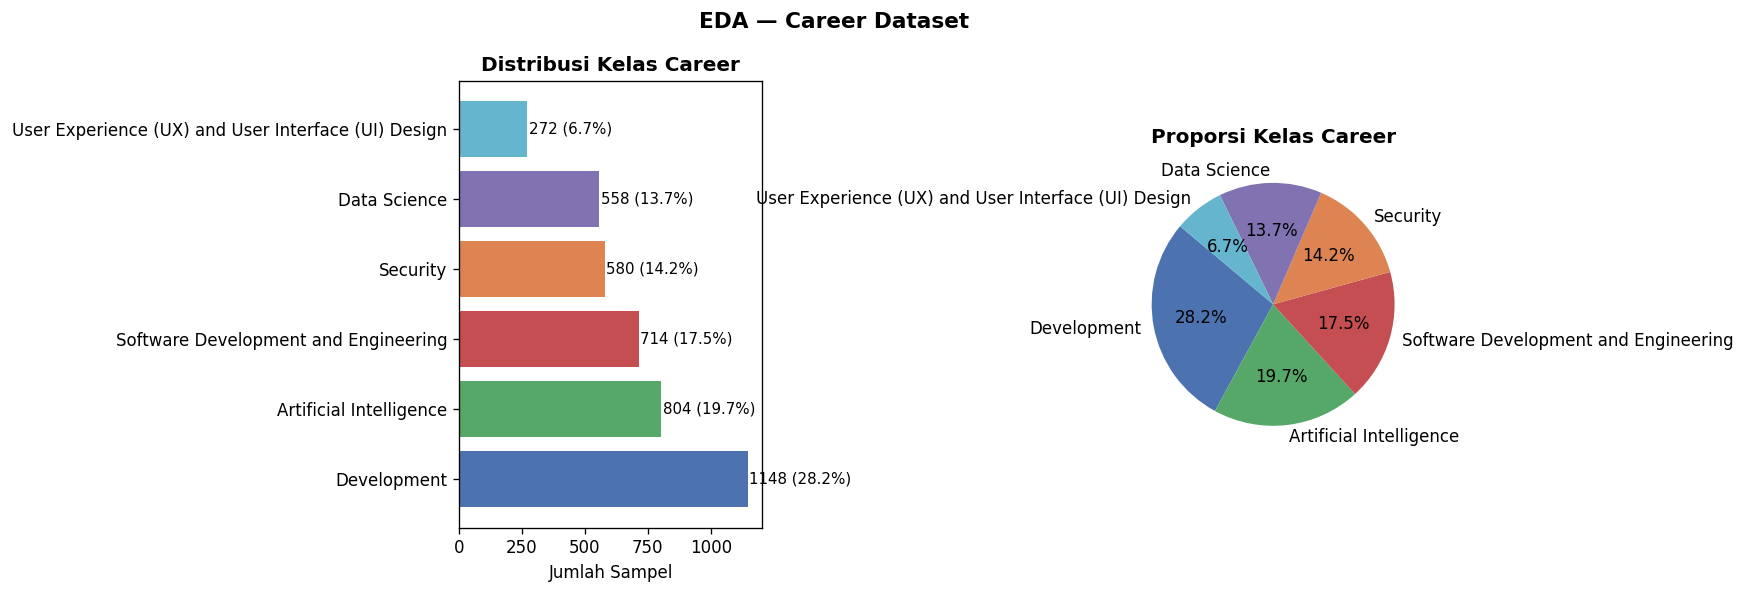


Interpretasi Distribusi Kelas:
  Total sampel      : 4076 data
  Kelas terbesar    : Development (1148 sampel, 28.2%)
  Kelas terkecil    : User Experience (UX) and User Interface (UI) Design (272 sampel, 6.7%)
  Rasio imbalance   : 4.22x


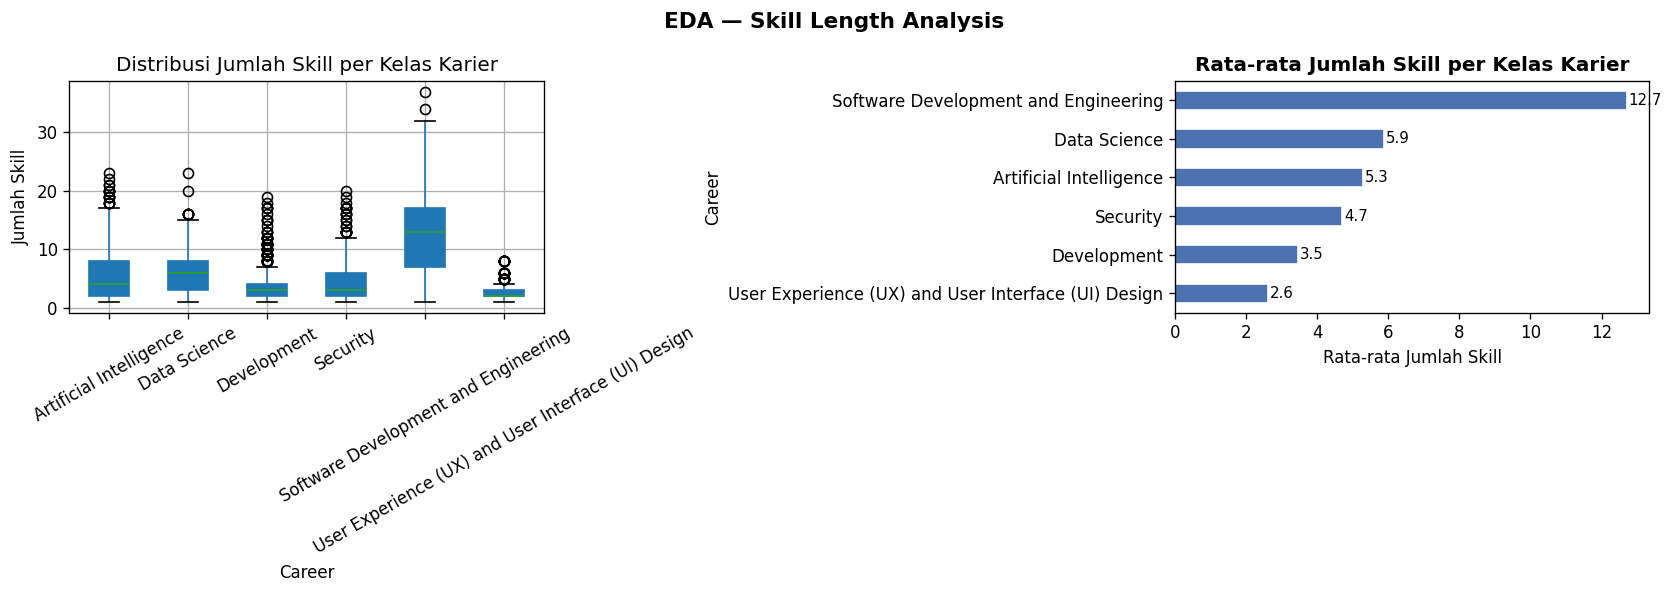

In [51]:
# ── Cell 3b: Exploratory Data Analysis (EDA) ─────────────────────────────────
class_dist = df['Career'].value_counts()

# 2. Rata-rata panjang skill text
df['Skill_Length'] = df['Skill'].apply(lambda x: len(str(x).split(',')))
print(f"\nPanjang Skill Text (jumlah skill per record):")
print(f"  Rata-rata : {df['Skill_Length'].mean():.1f} skill")
print(f"  Min       : {df['Skill_Length'].min()} skill")
print(f"  Max       : {df['Skill_Length'].max()} skill")

# ── Interpretasi Panjang Skill ────────────────────────────────
avg_len = df['Skill_Length'].mean()
print("\nInterpretasi Panjang Skill:")
print(f"  Rata-rata mahasiswa mencantumkan {avg_len:.1f} skill dalam profilnya.")

# Distribusi panjang skill per kelas
print("\n  Rata-rata jumlah skill per kelas karier:")
skill_per_career = df.groupby('Career')['Skill_Length'].mean().sort_values(ascending=False)
for career, avg in skill_per_career.items():
    print(f"    {career:<35} : {avg:.1f} skill")

# 3. Skill paling umum per kelas
print(f"\nTop 5 Skill Paling Sering per Kelas:")
for career in df['Career'].unique():
    subset     = df[df['Career'] == career]['Skill'].str.cat(sep=', ')
    all_skills = [s.strip() for s in subset.split(',')]
    top5       = pd.Series(all_skills).value_counts().head(5)
    print(f"\n  [{career}]")
    for skill, count in top5.items():
        print(f"    - {skill} ({count}x)")

print("  Analisis Skill Unik vs Overlap antar Kelas:")
career_skills = {}
for career in df['Career'].unique():
    subset = df[df['Career'] == career]['Skill'].str.cat(sep=', ')
    career_skills[career] = set([s.strip().lower() for s in subset.split(',')])

for career, skills in career_skills.items():
    unique_skills = skills.copy()
    for other_career, other_skills in career_skills.items():
        if other_career != career:
            unique_skills -= other_skills
    print(f"    {career:<35} : {len(unique_skills)} skill unik (tidak ada di kelas lain)")

# 4. Visualisasi distribusi kelas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#4C72B0','#55A868','#C44E52','#DD8452','#8172B2','#64B5CD']
axes[0].barh(class_dist.index, class_dist.values, color=colors)
axes[0].set_xlabel('Jumlah Sampel')
axes[0].set_title('Distribusi Kelas Career', fontweight='bold')
for i, v in enumerate(class_dist.values):
    axes[0].text(v + 5, i, f'{v} ({v/len(df)*100:.1f}%)', va='center', fontsize=9)

# Pie chart
axes[1].pie(class_dist.values, labels=class_dist.index,
            colors=colors, autopct='%1.1f%%', startangle=140)
axes[1].set_title('Proporsi Kelas Career', fontweight='bold')

plt.suptitle('EDA — Career Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

total       = len(df)
max_class   = class_dist.idxmax()
min_class   = class_dist.idxmin()
max_count   = class_dist.max()
min_count   = class_dist.min()
imbalance   = max_count / min_count

print("\nInterpretasi Distribusi Kelas:")
print(f"  Total sampel      : {total} data")
print(f"  Kelas terbesar    : {max_class} ({max_count} sampel, {max_count/total*100:.1f}%)")
print(f"  Kelas terkecil    : {min_class} ({min_count} sampel, {min_count/total*100:.1f}%)")
print(f"  Rasio imbalance   : {imbalance:.2f}x")

# ── Tambahan: Boxplot Panjang Skill per Kelas ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
df.boxplot(column='Skill_Length', by='Career', ax=axes[0],
           patch_artist=True)
axes[0].set_title('Distribusi Jumlah Skill per Kelas Karier', fontweight='bold')
axes[0].set_xlabel('Career')
axes[0].set_ylabel('Jumlah Skill')
axes[0].tick_params(axis='x', rotation=30)
plt.sca(axes[0])
plt.title('Distribusi Jumlah Skill per Kelas Karier')

# Bar chart rata-rata skill per kelas
skill_per_career.sort_values().plot(kind='barh', ax=axes[1],
    color='#4C72B0', edgecolor='white')
axes[1].set_title('Rata-rata Jumlah Skill per Kelas Karier', fontweight='bold')
axes[1].set_xlabel('Rata-rata Jumlah Skill')
for i, v in enumerate(skill_per_career.sort_values()):
    axes[1].text(v + 0.05, i, f'{v:.1f}', va='center', fontsize=9)

plt.suptitle('EDA — Skill Length Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [52]:
# ── Cell 4: Text Preprocessing ────────────────────────────────────────────────
# Langkah: lowercase → hapus tanda baca & angka → tokenisasi → hapus stopword

STOP_WORDS = {
    'and','or','the','a','an','in','of','to','is','for','with','on','at','by',
    'as','it','be','this','that','are','was','were','have','has','been','from',
    'not','but','if','so','do','can','will','would','could','should','may',
    'might','my','your','our','their','its','we','they','he','she','i','you',
    'me','him','her','us','them','what','which','who','how','when','where',
    'why','all','each','any','some','no','also','other','more','very',
    'about', 'abstract', 'thinking', 'abstract thinking',
    'knowledge', 'basic', 'understanding', 'using', 'use',
    'ability', 'skill', 'skills', 'experience', 'good',
}

def preprocess(text: str) -> str:
    text   = str(text).lower()                                   # 1. Lowercase
    text   = re.sub(r'[^a-z\s]', ' ', text)                      # 2. Hapus tanda baca & angka
    tokens = text.split()                                        # 3. Tokenisasi (split whitespace)
    tokens = [t for t in tokens                                  # 4. Hapus stopword & token pendek
              if t not in STOP_WORDS and len(t) > 1]
    return ' '.join(tokens)

df['Skill_Clean'] = df['Skill'].apply(preprocess)

print('Contoh preprocessing:')
print(f'  Sebelum : {df["Skill"].iloc[0][:100]}')
print(f'  Sesudah : {df["Skill_Clean"].iloc[0][:100]}')

Contoh preprocessing:
  Sebelum : Web Development, Mobile App Development, Artificial Intelligence (AI) and Machine Learning, Problem 
  Sesudah : web development mobile app development artificial intelligence ai machine learning problem solving a


In [53]:
# ── Cell 5: TF-IDF Vectorization ─────────────────────────────────────────────
# ngram_range=(1,2) → unigram + bigram untuk representasi skill lebih kaya
# sublinear_tf=True → gunakan log(1+tf) agar token frekuensi tinggi tidak dominan

vectorizer = TfidfVectorizer(
    max_features = 5000,
    ngram_range  = (1, 2),
    sublinear_tf = True
)

le = LabelEncoder()

X = vectorizer.fit_transform(df['Skill_Clean'])   # sparse matrix (4076, 5000)
y = le.fit_transform(df['Career'].astype(str))    # integer label 0–5

print(f'Dimensi TF-IDF : {X.shape}')
print(f'Pemetaan Label : {dict(zip(le.classes_, range(len(le.classes_))))}')

Dimensi TF-IDF : (4076, 5000)
Pemetaan Label : {'Artificial Intelligence': 0, 'Data Science': 1, 'Development': 2, 'Security': 3, 'Software Development and Engineering': 4, 'User Experience (UX) and User Interface (UI) Design': 5}


In [54]:
# ── Cell 6: Train-Test Split (80:20, stratified) ──────────────────────────────
# stratify=y memastikan proporsi kelas sama di train dan test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train : {X_train.shape[0]} sampel')
print(f'Test  : {X_test.shape[0]} sampel')

Train : 3260 sampel
Test  : 816 sampel


In [55]:
# ── Cell 7: Model Training ────────────────────────────────────────────────────
# 4 model dilatih dan dievaluasi; semua hasil disimpan di dict `results`

models = {
    'Naive Bayes'         : MultinomialNB(alpha=0.1),
    'Logistic Regression' : LogisticRegression(C=5, max_iter=1000, random_state=42),
    'Linear SVM'          : LinearSVC(C=1.0, max_iter=2000, random_state=42),
    'XGBoost'             : XGBClassifier(
                                n_estimators  = 300,
                                max_depth     = 6,
                                learning_rate = 0.1,
                                eval_metric   = 'mlogloss',
                                random_state  = 42,
                                n_jobs        = -1
                            ),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'model'     : model,
        'y_pred'    : y_pred,
        'accuracy'  : accuracy_score(y_test, y_pred),
        'precision' : precision_score(y_test, y_pred, average='macro', zero_division=0),
        'recall'    : recall_score(y_test, y_pred, average='macro', zero_division=0),
        'f1_macro'  : f1_score(y_test, y_pred, average='macro', zero_division=0),
    }
    mark = '✅' if results[name]['accuracy'] >= 0.90 else '⚠️'
    print(f"{mark} [{name}] Accuracy: {results[name]['accuracy']:.4f}")

✅ [Naive Bayes] Accuracy: 0.9228
✅ [Logistic Regression] Accuracy: 0.9473
✅ [Linear SVM] Accuracy: 0.9412
✅ [XGBoost] Accuracy: 0.9571


In [56]:
# ── Cell 7b: MLflow Logging ───────────────────────────────────────────────────
# Mencatat parameter, metrik, dan model ke MLflow — tidak mengubah hasil apapun

for name, r in results.items():

    with mlflow.start_run(run_name=name):

        # ── Catat parameter model ──────────────────────────────────────────
        if name == 'Naive Bayes':
            mlflow.log_param("alpha", 0.1)

        elif name == 'Logistic Regression':
            mlflow.log_param("C", 5)
            mlflow.log_param("max_iter", 1000)

        elif name == 'Linear SVM':
            mlflow.log_param("C", 1.0)
            mlflow.log_param("max_iter", 2000)

        elif name == 'XGBoost':
            mlflow.log_param("n_estimators", 300)
            mlflow.log_param("max_depth", 6)
            mlflow.log_param("learning_rate", 0.1)

        # ── Catat parameter TF-IDF (sama untuk semua model) ───────────────
        mlflow.log_param("tfidf_max_features", 5000)
        mlflow.log_param("tfidf_ngram_range",  "(1,2)")
        mlflow.log_param("tfidf_sublinear_tf", True)
        mlflow.log_param("test_size",          0.2)
        mlflow.log_param("random_state",       42)

        # ── Catat metrik hasil evaluasi ────────────────────────────────────
        mlflow.log_metric("accuracy",   r['accuracy'])
        mlflow.log_metric("precision",  r['precision'])
        mlflow.log_metric("recall",     r['recall'])
        mlflow.log_metric("f1_macro",   r['f1_macro'])

        # ── Catat model ────────────────────────────────────────────────────
        mlflow.sklearn.log_model(r['model'], artifact_path="model")

        print(f"✅ Logged: {name} | Acc: {r['accuracy']:.4f}")

print("\n📊 Semua model berhasil dicatat ke MLflow.")

2026/06/27 11:49:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/27 11:49:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/27 11:49:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/27 11:49:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

✅ Logged: Naive Bayes | Acc: 0.9228


2026/06/27 11:50:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/27 11:50:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Logged: Logistic Regression | Acc: 0.9473


2026/06/27 11:50:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/27 11:50:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Logged: Linear SVM | Acc: 0.9412
✅ Logged: XGBoost | Acc: 0.9571

📊 Semua model berhasil dicatat ke MLflow.


In [57]:
# ── Cell 8: Evaluation — Tabel Ringkasan Metrik ───────────────────────────────

summary = pd.DataFrame([
    {
        'Model'     : name,
        'Accuracy'  : round(r['accuracy'],  4),
        'Precision' : round(r['precision'], 4),
        'Recall'    : round(r['recall'],    4),
        'F1-Macro'  : round(r['f1_macro'],  4),
        '>90%?'     : '✅ Yes' if r['accuracy'] >= 0.90 else '❌ No'
    }
    for name, r in results.items()
])

print(summary.to_string(index=False))

              Model  Accuracy  Precision  Recall  F1-Macro >90%?
        Naive Bayes    0.9228     0.9264  0.9231    0.9242 ✅ Yes
Logistic Regression    0.9473     0.9560  0.9477    0.9509 ✅ Yes
         Linear SVM    0.9412     0.9491  0.9421    0.9449 ✅ Yes
            XGBoost    0.9571     0.9653  0.9594    0.9620 ✅ Yes


In [58]:
# ── Cell 8b: MLflow — Tampilkan Semua Run ────────────────────────────────────

runs = mlflow.search_runs()

# Pilih kolom yang relevan saja
cols = [
    'tags.mlflow.runName',
    'metrics.accuracy',
    'metrics.precision',
    'metrics.recall',
    'metrics.f1_macro',
]

display(
    runs[cols]
    .rename(columns={'tags.mlflow.runName': 'Model'})
    .sort_values('metrics.accuracy', ascending=False)
    .reset_index(drop=True)
)

,Model,metrics.accuracy,metrics.precision,metrics.recall,metrics.f1_macro
0,XGBoost,0.957108,0.965314,0.959445,0.962012
1,XGBoost,0.957108,0.965314,0.959445,0.962012
2,XGBoost,0.957108,0.965314,0.959445,0.962012
3,XGBoost,0.957108,0.965314,0.959445,0.962012
4,XGBoost,0.957108,0.965314,0.959445,0.962012
5,XGBoost,0.957108,0.965314,0.959445,0.962012
6,XGBoost,0.957108,0.965314,0.959445,0.962012
7,XGBoost,0.952206,0.960594,0.954901,0.957382
8,XGBoost,0.952206,0.960594,0.954901,0.957382
9,Logistic Regression,0.948529,0.957009,0.948838,0.952103


In [59]:
# ── Cell 9: Evaluation — Classification Report per Model ─────────────────────

for name, r in results.items():
    print(f"\n{'='*65}")
    print(f"  {name}  (Accuracy: {r['accuracy']:.4f})")
    print('='*65)
    print(classification_report(
        y_test, r['y_pred'],
        target_names=le.classes_,
        zero_division=0
    ))


  Naive Bayes  (Accuracy: 0.9228)
                                                     precision    recall  f1-score   support

                            Artificial Intelligence       0.93      0.96      0.94       161
                                       Data Science       0.92      0.94      0.93       112
                                        Development       0.93      0.97      0.95       230
                                           Security       0.94      0.90      0.92       116
               Software Development and Engineering       0.88      0.80      0.84       143
User Experience (UX) and User Interface (UI) Design       0.96      0.98      0.97        54

                                           accuracy                           0.92       816
                                          macro avg       0.93      0.92      0.92       816
                                       weighted avg       0.92      0.92      0.92       816


  Logistic Regression  (Accurac

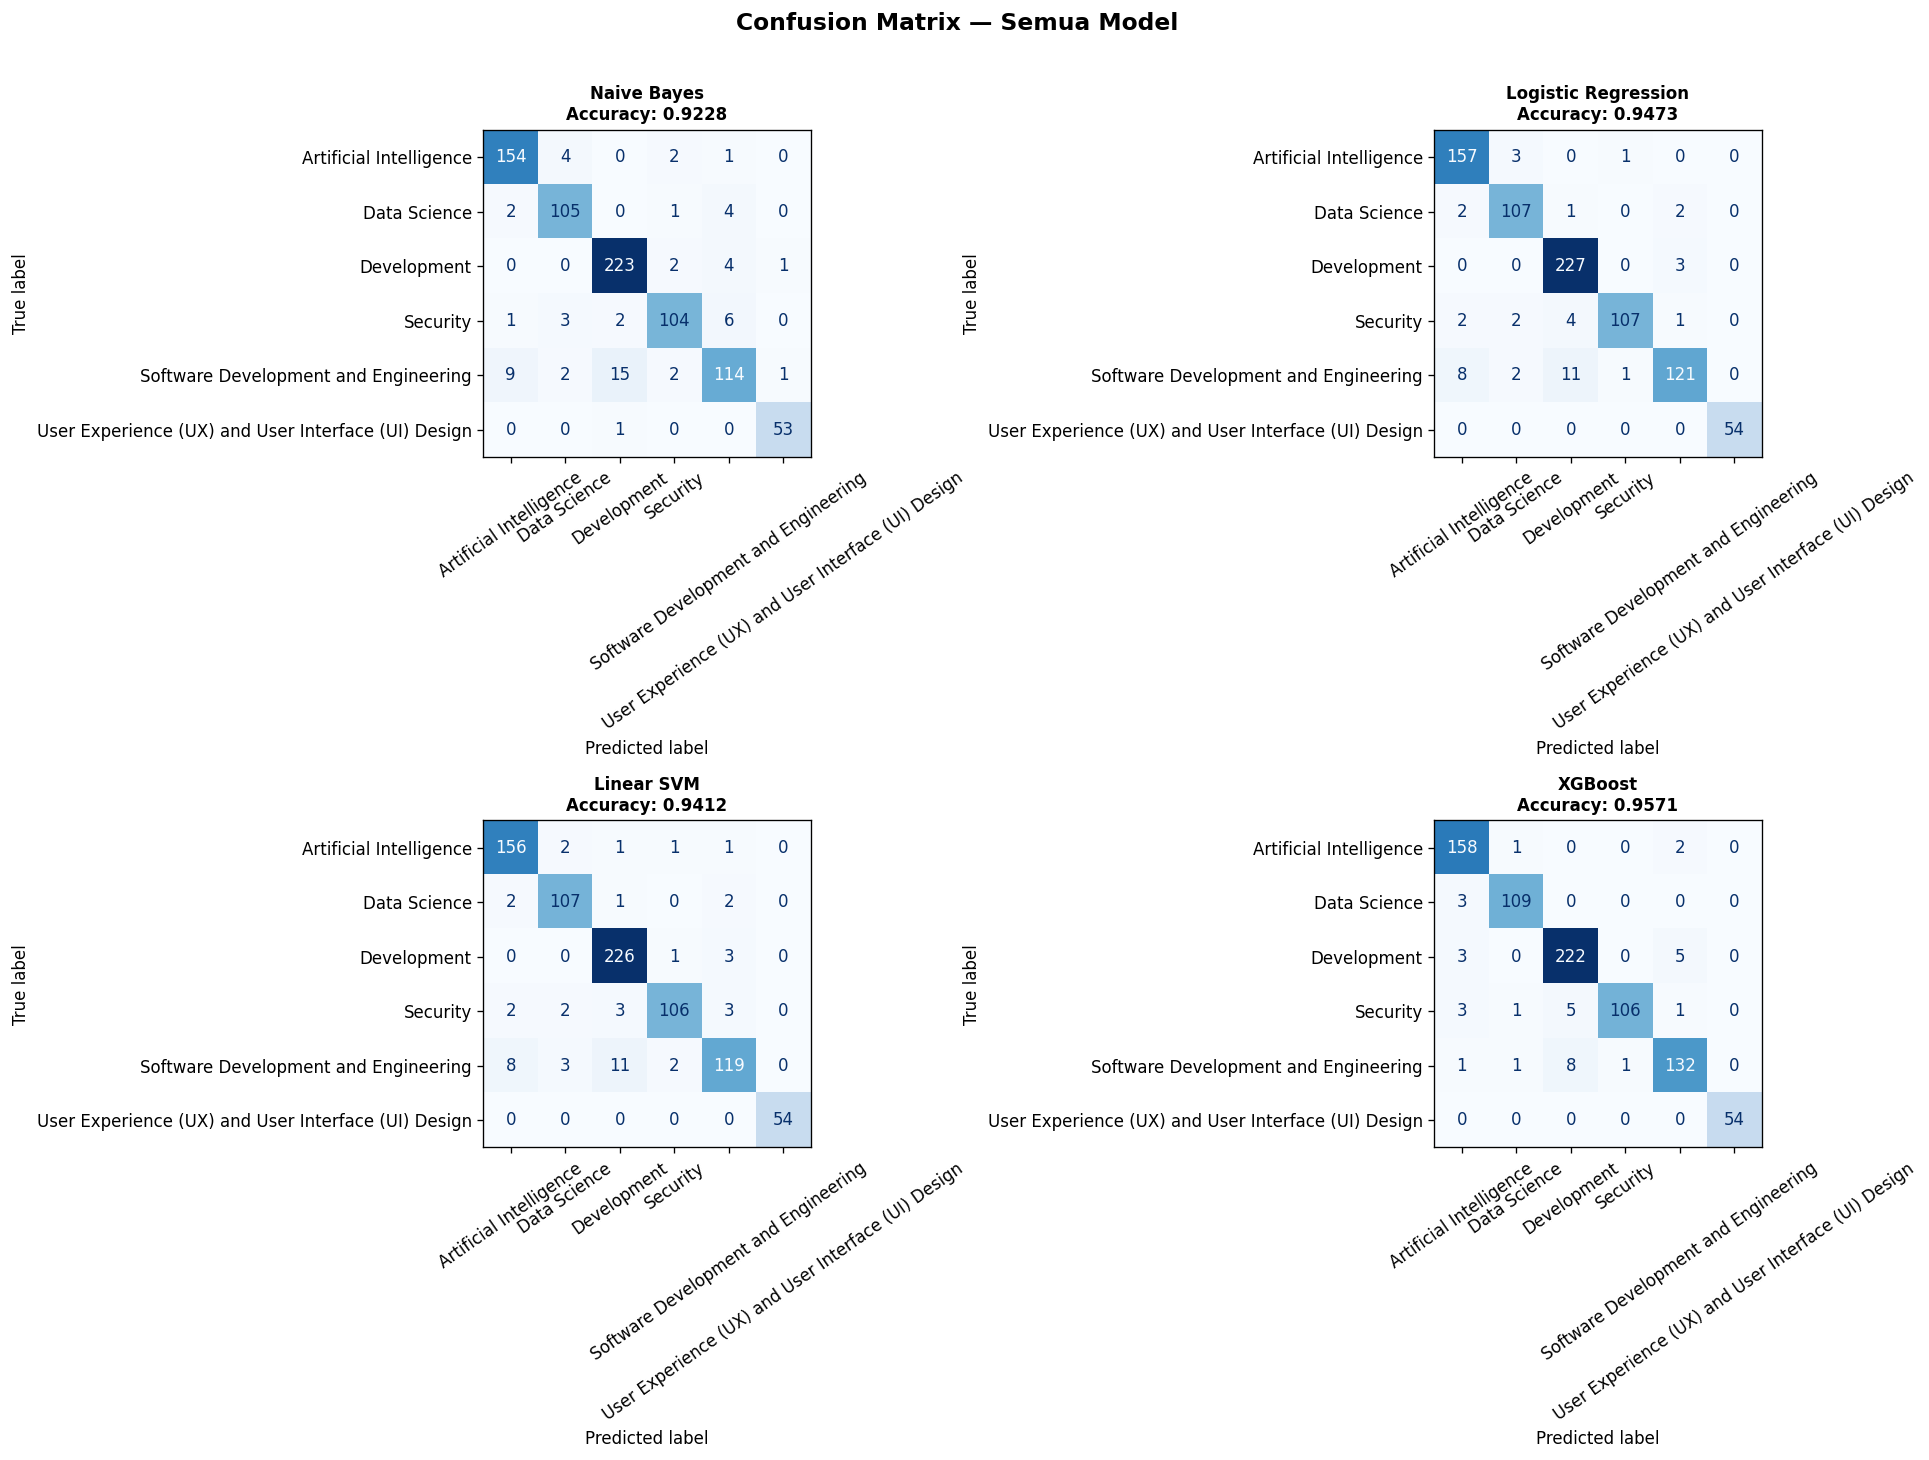

In [60]:
# ── Cell 10: Evaluation — Confusion Matrix (semua model) ─────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, (name, r) in zip(axes, results.items()):
    cm   = confusion_matrix(y_test, r['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, xticks_rotation=35, colorbar=False, cmap='Blues')
    ax.set_title(f"{name}\nAccuracy: {r['accuracy']:.4f}",
                 fontsize=10, fontweight='bold')

plt.suptitle('Confusion Matrix — Semua Model', y=1.01,
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

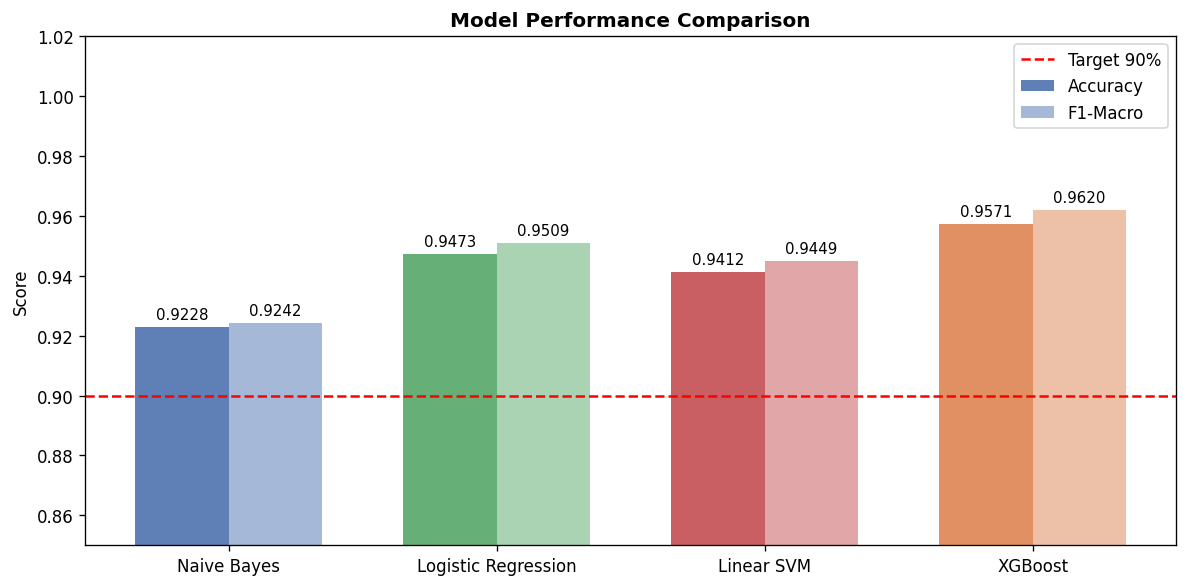

In [61]:
# ── Cell 11: Evaluation — Accuracy Bar Chart ─────────────────────────────────

names  = list(results.keys())
accs   = [results[n]['accuracy']  for n in names]
f1s    = [results[n]['f1_macro']  for n in names]
colors = ['#4C72B0', '#55A868', '#C44E52', '#DD8452']

x      = np.arange(len(names))
width  = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - width/2, accs, width, label='Accuracy',  color=colors, alpha=0.9)
b2 = ax.bar(x + width/2, f1s,  width, label='F1-Macro',  color=colors, alpha=0.5)
ax.bar_label(b1, fmt='%.4f', padding=3, fontsize=9)
ax.bar_label(b2, fmt='%.4f', padding=3, fontsize=9)
ax.axhline(0.90, color='red', linestyle='--', linewidth=1.5, label='Target 90%')
ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=10)
ax.set_ylim(0.85, 1.02)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

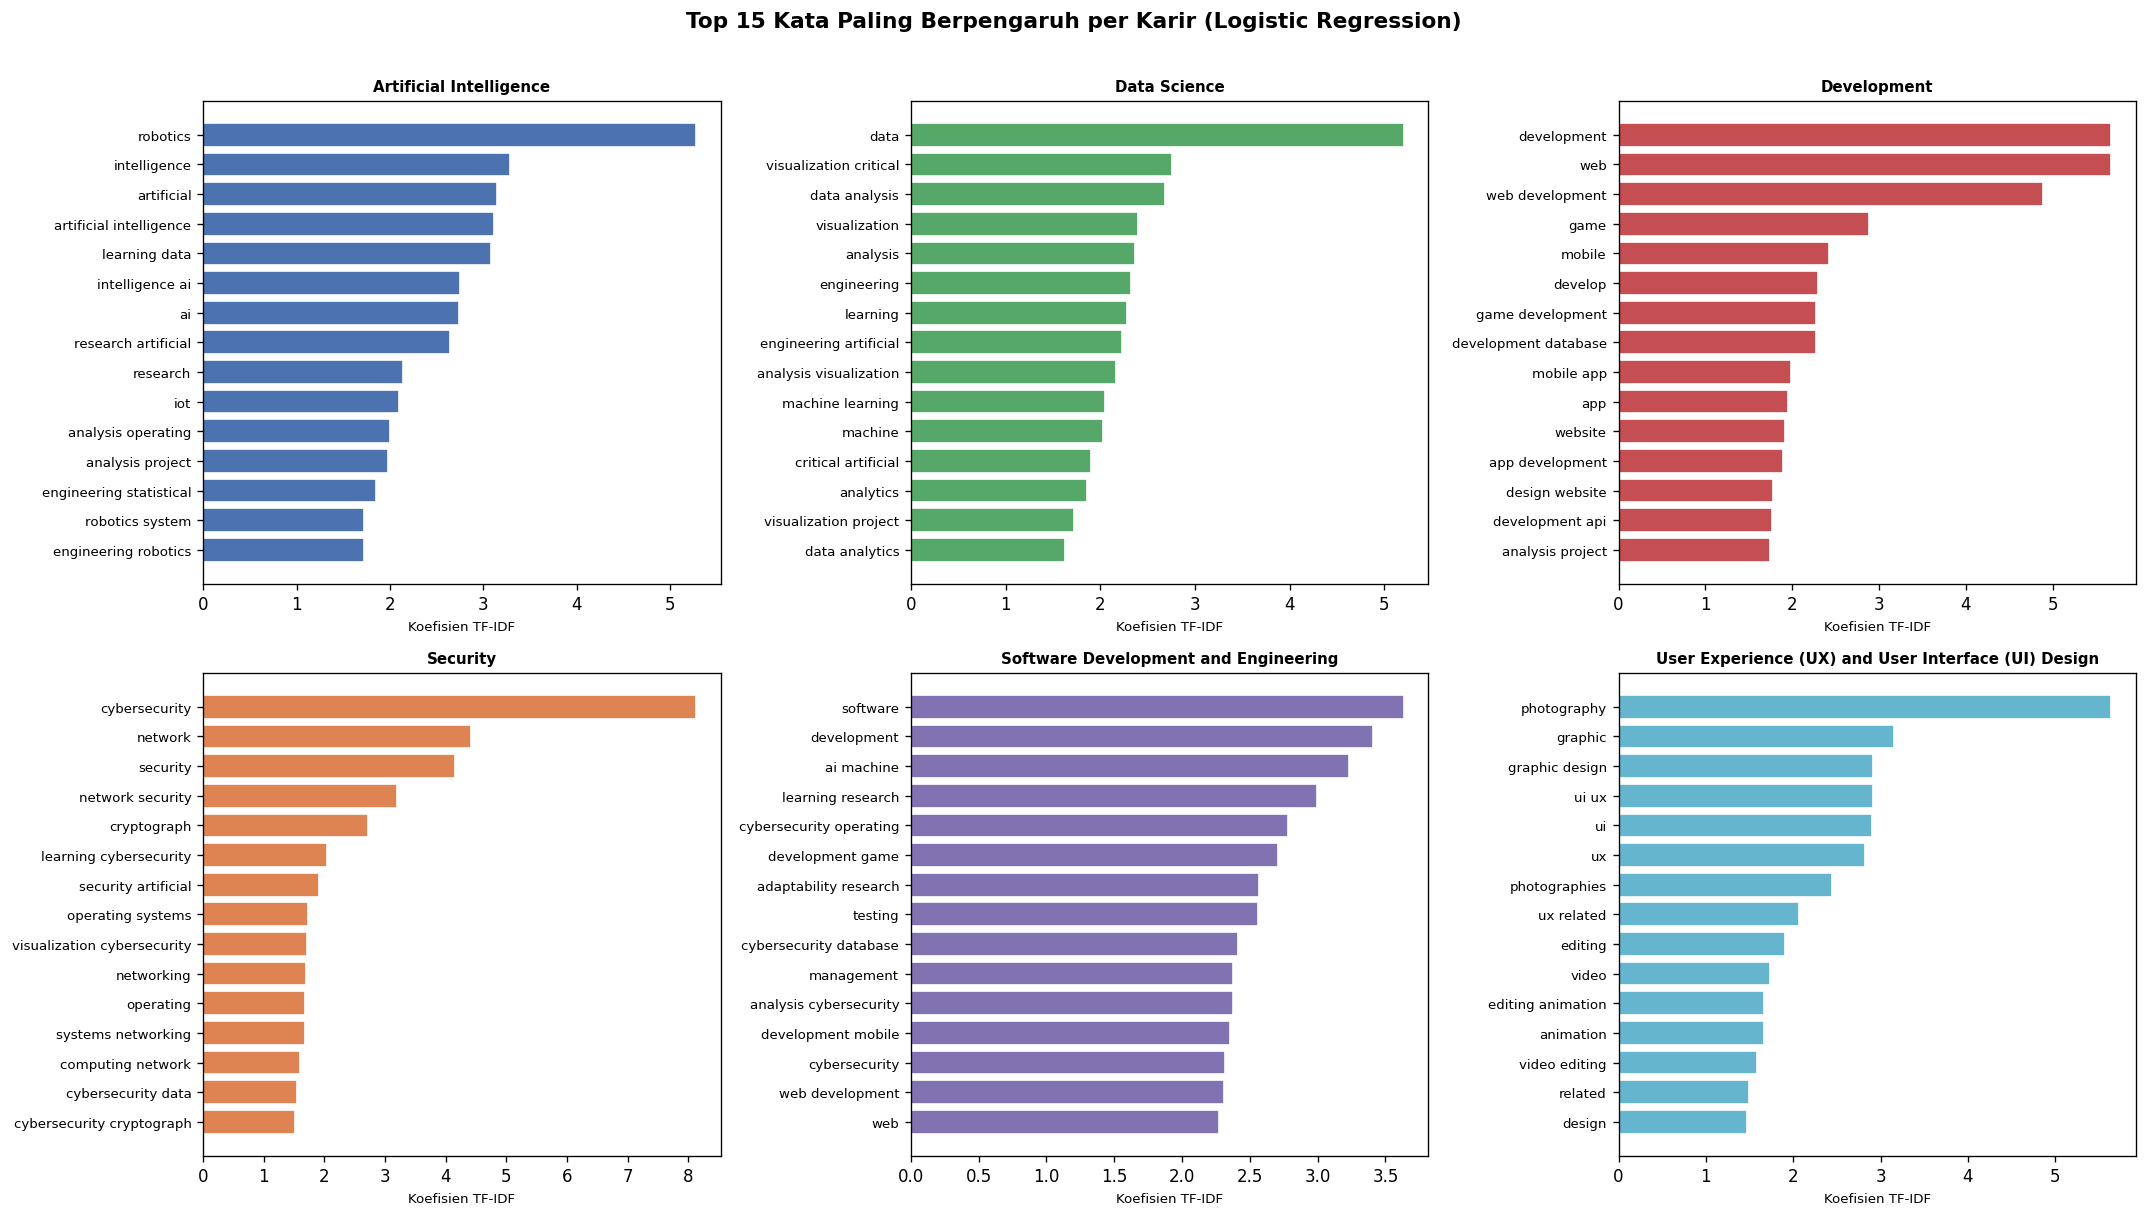

In [62]:
# Interpretability — Top Important Words per Kelas (Logistic Regression)
# Koefisien LogReg langsung menunjukkan bobot fitur per kelas → mudah diinterpretasi

lr_model   = results['Logistic Regression']['model']
feat_names = np.array(vectorizer.get_feature_names_out())
TOP_N      = 15

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes      = axes.flatten()
palette   = ['#4C72B0','#55A868','#C44E52','#DD8452','#8172B2','#64B5CD']

for i, (class_name, ax) in enumerate(zip(le.classes_, axes)):
    coef      = lr_model.coef_[i]
    top_idx   = np.argsort(coef)[-TOP_N:][::-1]
    top_words = feat_names[top_idx]
    top_vals  = coef[top_idx]

    ax.barh(range(TOP_N), top_vals[::-1], color=palette[i], edgecolor='white')
    ax.set_yticks(range(TOP_N))
    ax.set_yticklabels(top_words[::-1], fontsize=8)
    ax.set_xlabel('Koefisien TF-IDF', fontsize=8)
    ax.set_title(class_name, fontsize=9, fontweight='bold',
                 wrap=True)

plt.suptitle('Top 15 Kata Paling Berpengaruh per Karir (Logistic Regression)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [63]:
# Interpretability — SHAP Values (XGBoost)

xgb_model = results['XGBoost']['model']

# Batasi sample agar lebih cepat
N_SAMPLE = min(300, X_test.shape[0])
X_sample = X_test[:N_SAMPLE]

# TreeExplainer khusus untuk tree-based model
explainer = shap.TreeExplainer(xgb_model)

# Hitung SHAP values
shap_vals = explainer.shap_values(X_sample)

print("✅ SHAP computed")

if isinstance(shap_vals, list):
    print(f"Classes: {len(shap_vals)}")
    print(f"Shape per class: {shap_vals[0].shape}")
else:
    print(f"Shape: {np.array(shap_vals).shape}")

✅ SHAP computed
Shape: (300, 5000, 6)


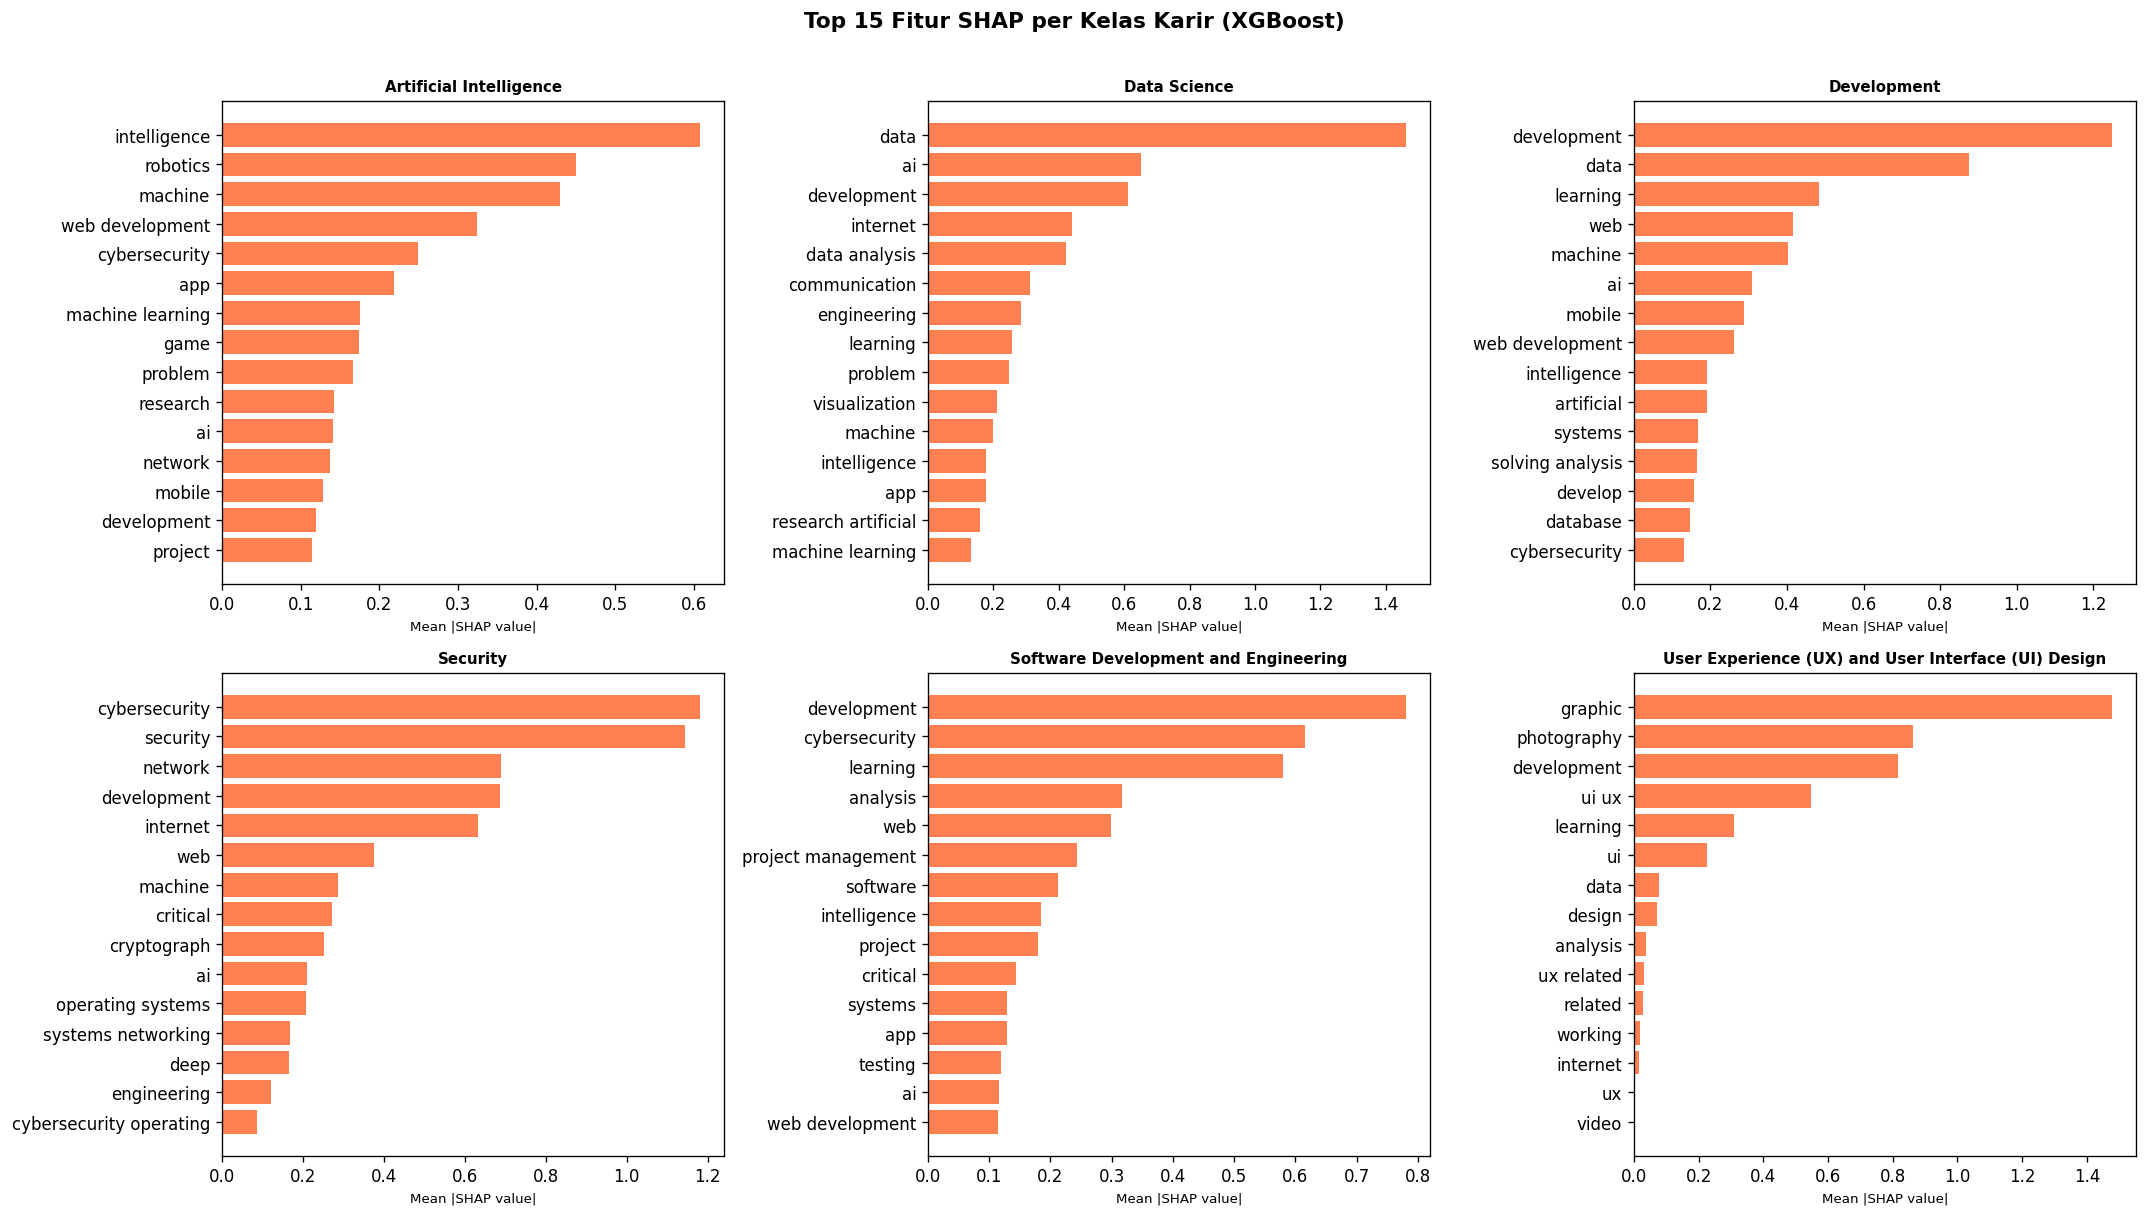

In [64]:
# Interpretability — SHAP Bar Plot per Kelas (XGBoost)

n_cls = len(le.classes_)

ncols = 3
nrows = (n_cls + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = axes.flatten()

class_names = [str(c) for c in le.classes_]

for idx in range(n_cls):

    ax = axes[idx]

    # Ambil SHAP untuk kelas ke-idx
    sv = shap_vals[:, :, idx]

    # Mean absolute SHAP
    mean_abs = np.abs(sv).mean(axis=0)

    # Top 15 fitur
    top_idx = np.argsort(mean_abs)[-15:][::-1]

    ax.barh(
        feat_names[top_idx][::-1],
        mean_abs[top_idx][::-1],
        color='coral'
    )

    ax.set_title(
        class_names[idx],
        fontweight='bold',
        fontsize=9,
        wrap=True
    )

    ax.set_xlabel('Mean |SHAP value|', fontsize=8)

for j in range(n_cls, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    'Top 15 Fitur SHAP per Kelas Karir (XGBoost)',
    fontsize=13,
    fontweight='bold',
    y=1.01
)

plt.tight_layout()
plt.show()

In [65]:
# ── Cell 15: Pilih Best Model & Demo Prediksi ─────────────────────────────────

best_name  = max(results, key=lambda n: results[n]['accuracy'])
best_model = results[best_name]['model']

print(f'🏆 Best Model : {best_name}')
print(f'   Accuracy   : {results[best_name]["accuracy"]:.4f}')
print(f'   F1-Macro   : {results[best_name]["f1_macro"]:.4f}')

# ── Demo prediksi ─────────────────────────────────────────────────────────────
sample_skills = [
    "machine learning deep learning python tensorflow data analysis",
    "web development react javascript html css ui ux prototyping figma",
    "penetration testing ethical hacking network security firewall kali linux",
    "flutter dart mobile app development android ios firebase",
    "data engineering pipeline sql spark cloud aws",
]

sample_clean  = [preprocess(s) for s in sample_skills]
sample_tfidf  = vectorizer.transform(sample_clean)
sample_preds  = best_model.predict(sample_tfidf)
sample_labels = le.inverse_transform(sample_preds)

print('\n📋 Demo Prediksi Karir Mahasiswa:')
print('─' * 70)
for skill, career in zip(sample_skills, sample_labels):
    print(f'  Skill   : {skill[:65]}')
    print(f'  Prediksi: {career}')
    print('  ·' * 35)

🏆 Best Model : XGBoost
   Accuracy   : 0.9571
   F1-Macro   : 0.9620

📋 Demo Prediksi Karir Mahasiswa:
──────────────────────────────────────────────────────────────────────
  Skill   : machine learning deep learning python tensorflow data analysis
  Prediksi: Data Science
  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·
  Skill   : web development react javascript html css ui ux prototyping figma
  Prediksi: Development
  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·
  Skill   : penetration testing ethical hacking network security firewall kal
  Prediksi: Security
  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·
  Skill   : flutter dart mobile app development android ios firebase
  Prediksi: Development
  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·
  Skill 

In [66]:
# ── Cell 16: Simpan & Download Model Terbaik ─────────────────────────────────
import joblib, os
from IPython.display import FileLink, display, HTML

# ── 2. Simpan model terbaik + artefak pendukung ───────────────────────────────
joblib.dump(best_model,  'model_xgb.pkl')        # best model
joblib.dump(vectorizer,  'vectorizer.pkl')        # TF-IDF vectorizer
joblib.dump(le,          'label_encoder.pkl')     # label encoder

# ── 3. Tampilkan info file ────────────────────────────────────────────────────
files = {
    'model_xgb.pkl'      : f'Best Model  ({best_name})',
    'vectorizer.pkl'     : 'TF-IDF Vectorizer',
    'label_encoder.pkl'  : 'Label Encoder',
}

print('✅ Semua file berhasil disimpan!\n')
print(f'{'File':<30} {'Keterangan':<30} {'Ukuran':>10}')
print('─' * 72)
for path, desc in files.items():
    size_kb = os.path.getsize(path) / 1024
    print(f'{path:<30} {desc:<30} {size_kb:>8.1f} KB')

# ── 4. Link download (klik langsung di Jupyter) ───────────────────────────────
print('\n📥 Klik link di bawah untuk download:')
for path in files:
    display(FileLink(path, result_html_prefix=f'⬇️  '))

# ── 5. Verifikasi: load ulang & test prediksi ─────────────────────────────────
print('\n🔍 Verifikasi model yang tersimpan...')
loaded_model      = joblib.load('model_xgb.pkl')
loaded_vectorizer = joblib.load('vectorizer.pkl')
loaded_le         = joblib.load('label_encoder.pkl')

test_input   = preprocess('machine learning deep learning python tensorflow')
test_vector  = loaded_vectorizer.transform([test_input])
test_pred    = loaded_model.predict(test_vector)
test_label   = loaded_le.inverse_transform(test_pred)[0]

print(f'  Input   : "machine learning deep learning python tensorflow"')
print(f'  Prediksi: {test_label}')
print(f'  Status  : ✅ Model siap digunakan di Streamlit!')

✅ Semua file berhasil disimpan!

File                           Keterangan                         Ukuran
────────────────────────────────────────────────────────────────────────
model_xgb.pkl                  Best Model  (XGBoost)            2393.4 KB
vectorizer.pkl                 TF-IDF Vectorizer                 219.2 KB
label_encoder.pkl              Label Encoder                       0.6 KB

📥 Klik link di bawah untuk download:


d:\BINUS\SEMESTER 4\Machine Learning\AOL\training\model_xgb.pkl

d:\BINUS\SEMESTER 4\Machine Learning\AOL\training\vectorizer.pkl

d:\BINUS\SEMESTER 4\Machine Learning\AOL\training\label_encoder.pkl


🔍 Verifikasi model yang tersimpan...
  Input   : "machine learning deep learning python tensorflow"
  Prediksi: Artificial Intelligence
  Status  : ✅ Model siap digunakan di Streamlit!


In [67]:
# ── Latency Measurement — Best Model ────────────────────────────────
import timeit

# Input tunggal (simulasi inferensi real-time 1 sampel)
SINGLE_INPUT = "machine learning deep learning python tensorflow data analysis"

def predict_single():
    clean  = preprocess(SINGLE_INPUT)
    vec    = vectorizer.transform([clean])
    return best_model.predict(vec)

# Input batch (seluruh test set)
def predict_batch():
    return best_model.predict(X_test)

# ── Pengukuran latency ────────────────────────────────────────────────────────
N_REPEAT = 1000   # jumlah repetisi untuk single inference
N_BATCH  = 50     # jumlah repetisi untuk batch inference

time_single = timeit.timeit(predict_single, number=N_REPEAT)
time_batch  = timeit.timeit(predict_batch,  number=N_BATCH)

avg_single_ms = (time_single / N_REPEAT) * 1000
avg_batch_ms  = (time_batch  / N_BATCH)  * 1000
throughput     = X_test.shape[0] / (avg_batch_ms / 1000)

print(f"{'='*55}")
print(f"  ⏱️  Latency Measurement — {best_name}")
print(f"{'='*55}")
print(f"  Single Inference  : {avg_single_ms:.4f} ms  (avg dari {N_REPEAT} run)")
print(f"  Batch Inference   : {avg_batch_ms:.2f} ms  (avg dari {N_BATCH} run, {X_test.shape[0]} sampel)")
print(f"  Throughput        : {throughput:,.0f} sampel/detik")
print(f"{'='*55}")

  ⏱️  Latency Measurement — XGBoost
  Single Inference  : 2.1352 ms  (avg dari 1000 run)
  Batch Inference   : 19.96 ms  (avg dari 50 run, 816 sampel)
  Throughput        : 40,887 sampel/detik
